## Data-Driven Airline Lounge Demand and Capacity Planning Case Study
## Business Problem
The demand for airline lounge services depends upon the characteristics of the flight (haul, destination regions), the arrival, and the time of the day. Moreover, the lounge size depends on the flight’s airplane capacity. The airport planning department needs a systematic approach to predict demand for lounges for future flights with a given level of detail.
Research Design

## This project will deliver a data-driven solution that can be automated to build a lookup table, which will estimate the possible demand for each flight and highlight potential capacity issues.

## The objectives of the study are the following:
• Determine flight groups;
• Calculate demand eligibility rates for each flight group;
• Develop the lookup table with demand estimations for future flights;
• Estimate demand for each flight;
• Analyze utilization and capacity challenges;
• Test demand growth/lounge capacity scenarios;
• Convert the analytical findings into the airport planning department’s actionable items.

## Approach

Flights will be grouped by haul, destination regions, and time of the day. For each group, historical lounge eligibility rates should be calculated and used to estimate expected demand for future flights.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Dataset Overview

The dataset contains historical airline flight information together with passenger eligibility information relevant to lounge demand.

The analysis uses flight characteristics, aircraft capacity, and lounge-eligibility passenger counts to find patterns which can assist with capacity planning.

In [16]:
file_path = "British Airways Summer Schedule Dataset - Forage Data Science Task 1.xlsx"

df = pd.read_excel(file_path)

### Flight Date Validation

The flight date is converted to datetime format and the minimum and maximum dates are checked to understand the historical observation period.

In [17]:
df["FLIGHT_DATE"] = pd.to_datetime(df["FLIGHT_DATE"])

print("Minimum flight date:", df["FLIGHT_DATE"].min())
print("Maximum flight date:", df["FLIGHT_DATE"].max())

Minimum flight date: 2025-04-01 00:00:00
Maximum flight date: 2025-10-30 00:00:00


### Initial Data Inspection

The first few records are inspected in order to understand the structure and key variables available in the dataset.

In [18]:
#exploratory data analysis
df.head()

,FLIGHT_DATE,FLIGHT_TIME,TIME_OF_DAY,AIRLINE_CD,FLIGHT_NO,DEPARTURE_STATION_CD,ARRIVAL_STATION_CD,ARRIVAL_COUNTRY,ARRIVAL_REGION,HAUL,AIRCRAFT_TYPE,FIRST_CLASS_SEATS,BUSINESS_CLASS_SEATS,ECONOMY_SEATS,TIER1_ELIGIBLE_PAX,TIER2_ELIGIBLE_PAX,TIER3_ELIGIBLE_PAX
0,2025-09-02,14:19:00,Afternoon,BA,BA5211,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,10,38
1,2025-06-10,06:42:00,Morning,BA,BA7282,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,7,28
2,2025-10-27,15:33:00,Afternoon,BA,BA1896,LHR,FRA,Germany,Europe,SHORT,A320,0,17,163,0,11,40
3,2025-06-15,18:29:00,Evening,BA,BA5497,LHR,IST,Turkey,Europe,SHORT,A320,0,8,172,0,16,54
4,2025-08-25,20:35:00,Evening,BA,BA1493,LHR,FRA,Germany,Europe,SHORT,A320,0,13,167,0,6,27


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   FLIGHT_DATE           10000 non-null  datetime64[ns]
 1   FLIGHT_TIME           10000 non-null  object        
 2   TIME_OF_DAY           10000 non-null  object        
 3   AIRLINE_CD            10000 non-null  object        
 4   FLIGHT_NO             10000 non-null  object        
 5   DEPARTURE_STATION_CD  10000 non-null  object        
 6   ARRIVAL_STATION_CD    10000 non-null  object        
 7   ARRIVAL_COUNTRY       10000 non-null  object        
 8   ARRIVAL_REGION        10000 non-null  object        
 9   HAUL                  10000 non-null  object        
 10  AIRCRAFT_TYPE         10000 non-null  object        
 11  FIRST_CLASS_SEATS     10000 non-null  int64         
 12  BUSINESS_CLASS_SEATS  10000 non-null  int64         
 13  ECONOMY_SEATS    

In [20]:
df.isnull().sum()

FLIGHT_DATE             0
FLIGHT_TIME             0
TIME_OF_DAY             0
AIRLINE_CD              0
FLIGHT_NO               0
DEPARTURE_STATION_CD    0
ARRIVAL_STATION_CD      0
ARRIVAL_COUNTRY         0
ARRIVAL_REGION          0
HAUL                    0
AIRCRAFT_TYPE           0
FIRST_CLASS_SEATS       0
BUSINESS_CLASS_SEATS    0
ECONOMY_SEATS           0
TIER1_ELIGIBLE_PAX      0
TIER2_ELIGIBLE_PAX      0
TIER3_ELIGIBLE_PAX      0
dtype: int64

### Data Quality Check

The dataset was checked for missing values and inconsistent data types before proceeding with the analysis further.

In [21]:
print("Haul:")
print(df["HAUL"].value_counts())

print("\nArrival Region:")
print(df["ARRIVAL_REGION"].value_counts())

print("\nTime of Day:")
print(df["TIME_OF_DAY"].value_counts())

Haul:
HAUL
SHORT    5975
LONG     4025
Name: count, dtype: int64

Arrival Region:
ARRIVAL_REGION
Europe           5975
North America    2658
Middle East       688
Asia              679
Name: count, dtype: int64

Time of Day:
TIME_OF_DAY
Morning      3530
Evening      2973
Afternoon    2305
Lunchtime    1192
Name: count, dtype: int64


## 3. Feature Engineering

Some Additional variables were derived from the raw flight information to support the operational segmentation and lounge-demand estimation.

Key derived features include:

- Flight hour
- Flight minute
- Time-of-day category
- Total aircraft seats

## 2. Feature Engineering

Flight-time and aircraft-capacity features are prepared for operational segmentation and demand estimation.


In [22]:
df["FLIGHT_HOUR"] = df["FLIGHT_TIME"].apply(
    lambda x: x.hour
)

df["FLIGHT_MINUTE"] = df["FLIGHT_TIME"].apply(
    lambda x: x.minute
)

In [23]:
df[[
    "FLIGHT_TIME",
    "FLIGHT_HOUR",
    "FLIGHT_MINUTE"
]].head()

,FLIGHT_TIME,FLIGHT_HOUR,FLIGHT_MINUTE
0,14:19:00,14,19
1,06:42:00,6,42
2,15:33:00,15,33
3,18:29:00,18,29
4,20:35:00,20,35


In [24]:
df['TOTAL_SEATS'] = (
    df['FIRST_CLASS_SEATS'] +
    df['BUSINESS_CLASS_SEATS'] +
    df['ECONOMY_SEATS']
)

In [25]:
df[[
    "FIRST_CLASS_SEATS",
    "BUSINESS_CLASS_SEATS",
    "ECONOMY_SEATS",
    "TOTAL_SEATS"
]].head()

,FIRST_CLASS_SEATS,BUSINESS_CLASS_SEATS,ECONOMY_SEATS,TOTAL_SEATS
0,8,49,178,235
1,8,49,178,235
2,0,17,163,180
3,0,8,172,180
4,0,13,167,180


In [26]:
df["TOTAL_LOUNGE_DEMAND"] = (
    df["TIER1_ELIGIBLE_PAX"]
    + df["TIER2_ELIGIBLE_PAX"]
    + df["TIER3_ELIGIBLE_PAX"]
)

In [27]:
df[[
    "FLIGHT_TIME",
    "FLIGHT_HOUR",
    "FLIGHT_MINUTE",
    "TIME_OF_DAY",
    "ARRIVAL_REGION",
    "HAUL",
    "AIRCRAFT_TYPE",
    "TOTAL_SEATS",
    "TOTAL_LOUNGE_DEMAND"
]].head()

,FLIGHT_TIME,FLIGHT_HOUR,FLIGHT_MINUTE,TIME_OF_DAY,ARRIVAL_REGION,HAUL,AIRCRAFT_TYPE,TOTAL_SEATS,TOTAL_LOUNGE_DEMAND
0,14:19:00,14,19,Afternoon,North America,LONG,B777,235,48
1,06:42:00,6,42,Morning,North America,LONG,B777,235,35
2,15:33:00,15,33,Afternoon,Europe,SHORT,A320,180,51
3,18:29:00,18,29,Evening,Europe,SHORT,A320,180,70
4,20:35:00,20,35,Evening,Europe,SHORT,A320,180,33


## 3. Flight Segmentation

Flights are grouped by **haul, arrival region, and time of day** to create practical operational segments.


## 4. Flight Segmentation

Flights are grouped using haul type, arrival region, and time of day to create meaningful operational segments.

This grouping provides a balance between capturing differences in lounge demand and maintaining enough historical observations within each group for reliable estimation.

In [28]:
flight_groups = (
    df.groupby(['HAUL','ARRIVAL_REGION','TIME_OF_DAY'])
    .size()
    .reset_index(name = 'NUMBER_OF_FLIGHTS')
)
flight_groups

,HAUL,ARRIVAL_REGION,TIME_OF_DAY,NUMBER_OF_FLIGHTS
0,LONG,Asia,Afternoon,152
1,LONG,Asia,Evening,206
2,LONG,Asia,Lunchtime,75
3,LONG,Asia,Morning,246
4,LONG,Middle East,Afternoon,159
5,LONG,Middle East,Evening,201
6,LONG,Middle East,Lunchtime,79
7,LONG,Middle East,Morning,249
8,LONG,North America,Afternoon,628
9,LONG,North America,Evening,783


In [29]:
lookup_table = (
    df.groupby(["HAUL", "ARRIVAL_REGION", "TIME_OF_DAY"])
      .agg(
          NUMBER_OF_FLIGHTS=("FLIGHT_NO", "count"),
          TOTAL_SEATS=("TOTAL_SEATS", "sum"),
          TIER1_PAX=("TIER1_ELIGIBLE_PAX", "sum"),
          TIER2_PAX=("TIER2_ELIGIBLE_PAX", "sum"),
          TIER3_PAX=("TIER3_ELIGIBLE_PAX", "sum")
      )
      .reset_index()
)
lookup_table

,HAUL,ARRIVAL_REGION,TIME_OF_DAY,NUMBER_OF_FLIGHTS,TOTAL_SEATS,TIER1_PAX,TIER2_PAX,TIER3_PAX
0,LONG,Asia,Afternoon,152,44373,75,1280,4805
1,LONG,Asia,Evening,206,59648,120,1602,6160
2,LONG,Asia,Lunchtime,75,21676,33,553,2172
3,LONG,Asia,Morning,246,71658,151,1890,7293
4,LONG,Middle East,Afternoon,159,47092,100,1259,4800
5,LONG,Middle East,Evening,201,58756,130,1523,5854
6,LONG,Middle East,Lunchtime,79,22490,43,607,2329
7,LONG,Middle East,Morning,249,72309,139,2014,7665
8,LONG,North America,Afternoon,628,183271,370,5059,19301
9,LONG,North America,Evening,783,228764,486,6160,23620


In [30]:
lookup_table["TIER1_PERCENT"] = (
    lookup_table["TIER1_PAX"] /
    lookup_table["TOTAL_SEATS"] * 100
)

lookup_table["TIER2_PERCENT"] = (
    lookup_table["TIER2_PAX"] /
    lookup_table["TOTAL_SEATS"] * 100
)

lookup_table["TIER3_PERCENT"] = (
    lookup_table["TIER3_PAX"] /
    lookup_table["TOTAL_SEATS"] * 100
)

In [31]:
lookup_table["NO_LOUNGE_PERCENT"] = (
    100 -
    lookup_table["TIER1_PERCENT"] -
    lookup_table["TIER2_PERCENT"] -
    lookup_table["TIER3_PERCENT"]
)

In [32]:
lookup_table

,HAUL,ARRIVAL_REGION,TIME_OF_DAY,NUMBER_OF_FLIGHTS,TOTAL_SEATS,TIER1_PAX,TIER2_PAX,TIER3_PAX,TIER1_PERCENT,TIER2_PERCENT,TIER3_PERCENT,NO_LOUNGE_PERCENT
0,LONG,Asia,Afternoon,152,44373,75,1280,4805,0.169022,2.884637,10.828657,86.117684
1,LONG,Asia,Evening,206,59648,120,1602,6160,0.201180,2.685756,10.327253,86.785810
2,LONG,Asia,Lunchtime,75,21676,33,553,2172,0.152242,2.551209,10.020299,87.276250
3,LONG,Asia,Morning,246,71658,151,1890,7293,0.210723,2.637528,10.177510,86.974239
4,LONG,Middle East,Afternoon,159,47092,100,1259,4800,0.212350,2.673490,10.192814,86.921345
5,LONG,Middle East,Evening,201,58756,130,1523,5854,0.221254,2.592076,9.963238,87.223433
6,LONG,Middle East,Lunchtime,79,22490,43,607,2329,0.191196,2.698977,10.355714,86.754113
7,LONG,Middle East,Morning,249,72309,139,2014,7665,0.192231,2.785269,10.600340,86.422160
8,LONG,North America,Afternoon,628,183271,370,5059,19301,0.201887,2.760393,10.531399,86.506321
9,LONG,North America,Evening,783,228764,486,6160,23620,0.212446,2.692731,10.325051,86.769771


In [33]:
percentage_columns = [
    "TIER1_PERCENT",
    "TIER2_PERCENT",
    "TIER3_PERCENT",
    "NO_LOUNGE_PERCENT"
]

lookup_table[percentage_columns] = (
    lookup_table[percentage_columns].round(2)
)

In [34]:
lookup_table

,HAUL,ARRIVAL_REGION,TIME_OF_DAY,NUMBER_OF_FLIGHTS,TOTAL_SEATS,TIER1_PAX,TIER2_PAX,TIER3_PAX,TIER1_PERCENT,TIER2_PERCENT,TIER3_PERCENT,NO_LOUNGE_PERCENT
0,LONG,Asia,Afternoon,152,44373,75,1280,4805,0.17,2.88,10.83,86.12
1,LONG,Asia,Evening,206,59648,120,1602,6160,0.20,2.69,10.33,86.79
2,LONG,Asia,Lunchtime,75,21676,33,553,2172,0.15,2.55,10.02,87.28
3,LONG,Asia,Morning,246,71658,151,1890,7293,0.21,2.64,10.18,86.97
4,LONG,Middle East,Afternoon,159,47092,100,1259,4800,0.21,2.67,10.19,86.92
5,LONG,Middle East,Evening,201,58756,130,1523,5854,0.22,2.59,9.96,87.22
6,LONG,Middle East,Lunchtime,79,22490,43,607,2329,0.19,2.70,10.36,86.75
7,LONG,Middle East,Morning,249,72309,139,2014,7665,0.19,2.79,10.60,86.42
8,LONG,North America,Afternoon,628,183271,370,5059,19301,0.20,2.76,10.53,86.51
9,LONG,North America,Evening,783,228764,486,6160,23620,0.21,2.69,10.33,86.77


## 6. Lounge Demand Lookup Table

Historical passenger eligibility counts are aggregated by flight group and converted into percentages.

These percentages form a reusable lookup table that allows lounge demand to be estimated for a future flight profile without requiring detailed passenger-level information.

In [35]:
lookup_table["TOTAL_PERCENT"] = (
    lookup_table["TIER1_PERCENT"] +
    lookup_table["TIER2_PERCENT"] +
    lookup_table["TIER3_PERCENT"] +
    lookup_table["NO_LOUNGE_PERCENT"]
)

lookup_table[
    ["HAUL", "ARRIVAL_REGION", "TIME_OF_DAY", "TOTAL_PERCENT"]
]

,HAUL,ARRIVAL_REGION,TIME_OF_DAY,TOTAL_PERCENT
0,LONG,Asia,Afternoon,100.00
1,LONG,Asia,Evening,100.01
2,LONG,Asia,Lunchtime,100.00
3,LONG,Asia,Morning,100.00
4,LONG,Middle East,Afternoon,99.99
5,LONG,Middle East,Evening,99.99
6,LONG,Middle East,Lunchtime,100.00
7,LONG,Middle East,Morning,100.00
8,LONG,North America,Afternoon,100.00
9,LONG,North America,Evening,100.00


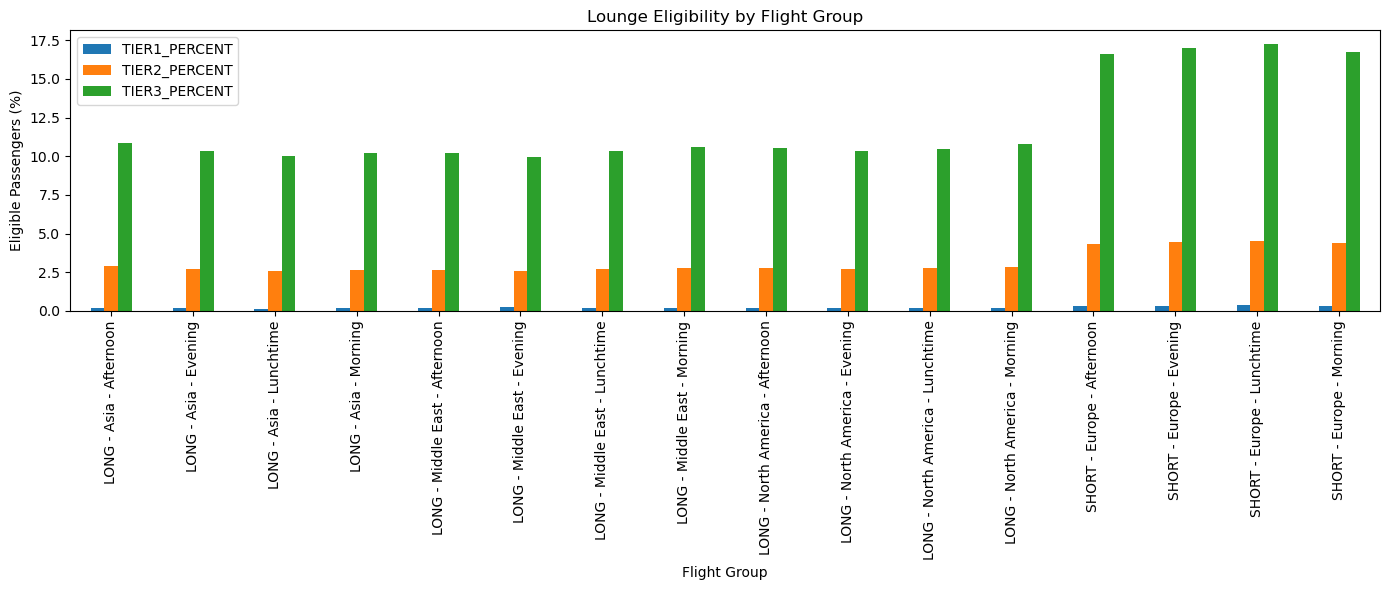

In [36]:
chart_data = lookup_table.copy()

chart_data["GROUP"] = (
    chart_data["HAUL"] + " - " +
    chart_data["ARRIVAL_REGION"] + " - " +
    chart_data["TIME_OF_DAY"]
)

chart_data.set_index("GROUP")[
    ["TIER1_PERCENT", "TIER2_PERCENT", "TIER3_PERCENT"]
].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Lounge Eligibility by Flight Group")
plt.xlabel("Flight Group")
plt.ylabel("Eligible Passengers (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Passenger Lounge Eligibility Analysis

Historical lounge-eligibility counts are examined across the defined flight groups.


## 5. Passenger Lounge Eligibility Analysis

Passenger eligibility was analyzed across the defined flight groups.

The three lounge eligibility tiers were examined separately to determine how the composition of eligible passengers varies between flight profiles.

In [37]:
df["TOTAL_LOUNGE_DEMAND"] = (
    df["TIER1_ELIGIBLE_PAX"] +
    df["TIER2_ELIGIBLE_PAX"] +
    df["TIER3_ELIGIBLE_PAX"]
)

In [38]:
df[[
    "TIER1_ELIGIBLE_PAX",
    "TIER2_ELIGIBLE_PAX",
    "TIER3_ELIGIBLE_PAX",
    "TOTAL_LOUNGE_DEMAND"
]].head()

,TIER1_ELIGIBLE_PAX,TIER2_ELIGIBLE_PAX,TIER3_ELIGIBLE_PAX,TOTAL_LOUNGE_DEMAND
0,0,10,38,48
1,0,7,28,35
2,0,11,40,51
3,0,16,54,70
4,0,6,27,33


## 7. Predictive Model Evaluation

Baseline Linear Regression and Random Forest models are evaluated to test whether the available flight-level variables provide useful predictive power.


In [39]:
features = [
    "FLIGHT_HOUR",
    "FLIGHT_MINUTE",
    "TIME_OF_DAY",
    "ARRIVAL_REGION",
    "HAUL",
    "AIRCRAFT_TYPE",
    "FIRST_CLASS_SEATS",
    "BUSINESS_CLASS_SEATS",
    "ECONOMY_SEATS",
    "TOTAL_SEATS"
]

X = df[features]
y = df["TOTAL_LOUNGE_DEMAND"]

In [40]:
df_model = df.sort_values("FLIGHT_DATE").reset_index(drop=True)

df_model[["FLIGHT_DATE", "TOTAL_LOUNGE_DEMAND"]].head()

,FLIGHT_DATE,TOTAL_LOUNGE_DEMAND
0,2025-04-01,32
1,2025-04-01,46
2,2025-04-01,97
3,2025-04-01,0
4,2025-04-01,3


In [41]:
df_model[["FLIGHT_DATE", "TOTAL_LOUNGE_DEMAND"]].tail()

,FLIGHT_DATE,TOTAL_LOUNGE_DEMAND
9995,2025-10-30,40
9996,2025-10-30,45
9997,2025-10-30,13
9998,2025-10-30,3
9999,2025-10-30,16


In [42]:
df_model["FLIGHT_DATE"].is_monotonic_increasing

True

In [43]:
split_index = int(len(df_model) * 0.8)

train = df_model.iloc[:split_index]
test = df_model.iloc[split_index:]

print("Training rows:", len(train))
print("Testing rows:", len(test))

print("Training period:", train["FLIGHT_DATE"].min(), "to", train["FLIGHT_DATE"].max())
print("Testing period:", test["FLIGHT_DATE"].min(), "to", test["FLIGHT_DATE"].max())

Training rows: 8000
Testing rows: 2000
Training period: 2025-04-01 00:00:00 to 2025-09-16 00:00:00
Testing period: 2025-09-16 00:00:00 to 2025-10-30 00:00:00


In [44]:
X_train = train[features]
X_test = test[features]

y_train = train["TOTAL_LOUNGE_DEMAND"]
y_test = test["TOTAL_LOUNGE_DEMAND"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 10)
X_test: (2000, 10)
y_train: (8000,)
y_test: (2000,)


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "TIME_OF_DAY",
    "ARRIVAL_REGION",
    "HAUL",
    "AIRCRAFT_TYPE"
]

numerical_features = [
    "FLIGHT_HOUR",
    "FLIGHT_MINUTE",
    "FIRST_CLASS_SEATS",
    "BUSINESS_CLASS_SEATS",
    "ECONOMY_SEATS",
    "TOTAL_SEATS"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [48]:
y_pred_baseline = baseline_model.predict(X_test)

print(y_pred_baseline[:10])

[37.76386698 38.93888387 39.62581775 38.87380031 38.99635082 39.24155817
 38.45869477 39.5832842  38.57444236 38.95440555]


In [49]:
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

rmse_baseline = np.sqrt(
    mean_squared_error(y_test, y_pred_baseline)
)

r2_baseline = r2_score(y_test, y_pred_baseline)

print("Baseline Model Performance")
print("--------------------------")
print("MAE :", round(mae_baseline, 2))
print("RMSE:", round(rmse_baseline, 2))
print("R²  :", round(r2_baseline, 2))

Baseline Model Performance
--------------------------
MAE : 16.64
RMSE: 20.62
R²  : -0.0


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [51]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [52]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[30.77       36.89966667 37.70416667 32.09666667 44.53666667 49.89833333
 33.655      47.36125    24.8765     49.69166667]


In [53]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 2))

Random Forest Performance
-------------------------
MAE : 18.18
RMSE: 22.81
R²  : -0.22


In [54]:
print(df_model["TOTAL_LOUNGE_DEMAND"].describe())

count    10000.000000
mean        38.981000
std         20.404991
min          0.000000
25%         24.000000
50%         39.000000
75%         53.000000
max        121.000000
Name: TOTAL_LOUNGE_DEMAND, dtype: float64


In [55]:
print(df_model[[
    "TOTAL_SEATS",
    "TOTAL_LOUNGE_DEMAND"
]].corr())

                     TOTAL_SEATS  TOTAL_LOUNGE_DEMAND
TOTAL_SEATS                1.000               -0.003
TOTAL_LOUNGE_DEMAND       -0.003                1.000


In [56]:
group_analysis = df_model.groupby(
    ["HAUL", "ARRIVAL_REGION", "TIME_OF_DAY"]
)["TOTAL_LOUNGE_DEMAND"].agg(
    ["mean", "median", "std", "min", "max", "count"]
).round(2)

group_analysis

mean  median    std  min  max  count
HAUL  ARRIVAL_REGION TIME_OF_DAY                                       
LONG  Asia           Afternoon    40.53    42.5  21.62    0  106    152
                     Evening      38.26    38.0  21.20    0   92    206
                     Lunchtime    36.77    36.0  19.16    0   96     75
                     Morning      37.94    39.0  21.37    0   90    246
      Middle East    Afternoon    38.74    39.0  21.02    0   95    159
                     Evening      37.35    40.0  19.52    0   82    201
                     Lunchtime    37.71    40.0  18.71    0   79     79
                     Morning      39.43    38.0  20.42    0   90    249
      North America  Afternoon    39.38    39.0  20.46    0   97    628
                     Evening      38.65    39.0  20.96    0  102    783
                     Lunchtime    39.14    39.0  20.37    0  105    281
                     Morning      40.35    40.0  20.48    0  121    966
SHORT Europe         Afternoon    38.24    38.0  19.74    0  104   1366
                     Evening      39.20    39.0  20.77    0  120   1783
                     Lunchtime    39.99    40.0  20.67    0  110    757
                     Morning      38.59    39.0  20.01    0  112   2069

In [57]:
aircraft_analysis = df_model.groupby(
    "AIRCRAFT_TYPE"
)["TOTAL_LOUNGE_DEMAND"].agg(
    ["mean", "median", "std", "min", "max", "count"]
).round(2)

aircraft_analysis.sort_values("mean", ascending=False)

,mean,median,std,min,max,count
AIRCRAFT_TYPE,,,,,,
B787,39.62,39.5,20.71,0,109,1236
B777,39.03,39.0,20.79,0,105,1878
A350,38.89,39.0,19.74,0,105,535
A320,38.87,39.0,20.27,0,120,5975
A380,38.57,38.0,20.65,0,121,376


In [58]:
tier_analysis = df_model[
    [
        "TIER1_ELIGIBLE_PAX",
        "TIER2_ELIGIBLE_PAX",
        "TIER3_ELIGIBLE_PAX"
    ]
].describe()

tier_analysis

,TIER1_ELIGIBLE_PAX,TIER2_ELIGIBLE_PAX,TIER3_ELIGIBLE_PAX
count,10000.000000,10000.000000,10000.000000
mean,0.607700,7.951900,30.421400
std,1.006232,5.130752,15.284233
min,0.000000,0.000000,0.000000
25%,0.000000,4.000000,20.000000
50%,0.000000,8.000000,30.000000
75%,1.000000,11.000000,41.000000
max,20.000000,29.000000,92.000000


In [59]:
tier_correlations = df_model[
    [
        "TIER1_ELIGIBLE_PAX",
        "TIER2_ELIGIBLE_PAX",
        "TIER3_ELIGIBLE_PAX",
        "TOTAL_LOUNGE_DEMAND"
    ]
].corr()

tier_correlations

,TIER1_ELIGIBLE_PAX,TIER2_ELIGIBLE_PAX,TIER3_ELIGIBLE_PAX,TOTAL_LOUNGE_DEMAND
TIER1_ELIGIBLE_PAX,1.000000,-0.010590,-0.010449,0.038823
TIER2_ELIGIBLE_PAX,-0.010590,1.000000,0.993690,0.995241
TIER3_ELIGIBLE_PAX,-0.010449,0.993690,1.000000,0.998388
TOTAL_LOUNGE_DEMAND,0.038823,0.995241,0.998388,1.000000


In [60]:
seat_correlations = df_model[
    [
        "FIRST_CLASS_SEATS",
        "BUSINESS_CLASS_SEATS",
        "ECONOMY_SEATS",
        "TOTAL_SEATS",
        "TIER1_ELIGIBLE_PAX",
        "TIER2_ELIGIBLE_PAX",
        "TIER3_ELIGIBLE_PAX",
        "TOTAL_LOUNGE_DEMAND"
    ]
].corr().round(3)

seat_correlations

,FIRST_CLASS_SEATS,BUSINESS_CLASS_SEATS,ECONOMY_SEATS,TOTAL_SEATS,TIER1_ELIGIBLE_PAX,TIER2_ELIGIBLE_PAX,TIER3_ELIGIBLE_PAX,TOTAL_LOUNGE_DEMAND
FIRST_CLASS_SEATS,1.000,0.751,0.340,0.530,-0.009,-0.000,0.000,-0.000
BUSINESS_CLASS_SEATS,0.751,1.000,0.691,0.852,-0.017,0.001,0.002,0.001
ECONOMY_SEATS,0.340,0.691,1.000,0.966,-0.017,-0.003,-0.004,-0.004
TOTAL_SEATS,0.530,0.852,0.966,1.000,-0.018,-0.002,-0.002,-0.003
TIER1_ELIGIBLE_PAX,-0.009,-0.017,-0.017,-0.018,1.000,-0.011,-0.010,0.039
TIER2_ELIGIBLE_PAX,-0.000,0.001,-0.003,-0.002,-0.011,1.000,0.994,0.995
TIER3_ELIGIBLE_PAX,0.000,0.002,-0.004,-0.002,-0.010,0.994,1.000,0.998
TOTAL_LOUNGE_DEMAND,-0.000,0.001,-0.004,-0.003,0.039,0.995,0.998,1.000


In [61]:
route_analysis = df_model.groupby(
    ["DEPARTURE_STATION_CD", "ARRIVAL_STATION_CD"]
)["TOTAL_LOUNGE_DEMAND"].agg(
    ["mean", "median", "std", "min", "max", "count"]
).sort_values("mean", ascending=False)

route_analysis.head(20)

mean  median        std  min  \
DEPARTURE_STATION_CD ARRIVAL_STATION_CD                                      
LHR                  DFW                 40.410413    40.0  20.971205    0   
                     ORD                 39.885926    39.0  19.939308    0   
                     MUC                 39.735166    39.0  20.114330    0   
                     BCN                 39.545736    39.0  20.958325    0   
                     IST                 39.543077    38.0  20.750306    0   
                     FRA                 39.429972    40.0  20.513841    0   
                     AMS                 39.177847    39.0  20.158502    0   
                     LAX                 39.087087    39.0  20.364312    0   
                     ZRH                 38.622257    38.0  20.027296    0   
                     JFK                 38.596386    38.0  21.157024    0   
                     CDG                 38.594384    39.0  19.526126    0   
                     HND                 38.488954    39.0  21.129593    0   
                     DXB                 38.463663    39.0  20.087186    0   
                     MAD                 38.261516    38.0  20.012718    0   
                     VIE                 36.919355    36.0  20.243255    0   

                                         max  count  
DEPARTURE_STATION_CD ARRIVAL_STATION_CD              
LHR                  DFW                 121    653  
                     ORD                  97    675  
                     MUC                 112    691  
                     BCN                 106    645  
                     IST                 104    650  
                     FRA                 104    714  
                     AMS                 104    641  
                     LAX                 101    666  
                     ZRH                 120    638  
                     JFK                 109    664  
                     CDG                  94    641  
                     HND                 106    679  
                     DXB                  95    688  
                     MAD                 104    673  
                     VIE                  99    682

In [62]:
print("Unique departure airports:",
      df_model["DEPARTURE_STATION_CD"].nunique())

print("Unique arrival airports:",
      df_model["ARRIVAL_STATION_CD"].nunique())

print("Unique routes:",
      df_model.groupby(
          ["DEPARTURE_STATION_CD", "ARRIVAL_STATION_CD"]
      ).ngroups)

Unique departure airports: 1
Unique arrival airports: 15
Unique routes: 15


In [63]:
arrival_analysis = df_model.groupby(
    "ARRIVAL_STATION_CD"
)["TOTAL_LOUNGE_DEMAND"].agg(
    ["mean", "median", "std", "min", "max", "count"]
).sort_values("mean", ascending=False).round(2)

arrival_analysis

,mean,median,std,min,max,count
ARRIVAL_STATION_CD,,,,,,
DFW,40.41,40.0,20.97,0,121,653
ORD,39.89,39.0,19.94,0,97,675
MUC,39.74,39.0,20.11,0,112,691
BCN,39.55,39.0,20.96,0,106,645
IST,39.54,38.0,20.75,0,104,650
FRA,39.43,40.0,20.51,0,104,714
AMS,39.18,39.0,20.16,0,104,641
LAX,39.09,39.0,20.36,0,101,666
ZRH,38.62,38.0,20.03,0,120,638


In [64]:
arrival_analysis["mean"].max() - arrival_analysis["mean"].min()

3.489999999999995

In [65]:
monthly_demand = df_model.groupby(
    df_model["FLIGHT_DATE"].dt.to_period("M")
)["TOTAL_LOUNGE_DEMAND"].agg(
    ["mean", "median", "std", "count"]
).round(2)

monthly_demand

,mean,median,std,count
FLIGHT_DATE,,,,
2025-04,39.10,39.0,20.80,1436
2025-05,39.81,39.0,20.46,1488
2025-06,38.43,37.0,20.80,1483
2025-07,38.46,39.0,19.66,1389
2025-08,38.93,39.0,20.01,1429
2025-09,38.93,39.0,20.65,1430
2025-10,39.20,39.0,20.40,1345


In [66]:
daily_demand = df_model.groupby(
    "FLIGHT_DATE"
)["TOTAL_LOUNGE_DEMAND"].mean()

daily_demand.describe().round(2)

count    210.00
mean      38.98
std        2.83
min       31.82
25%       37.07
50%       38.67
75%       41.02
max       46.71
Name: TOTAL_LOUNGE_DEMAND, dtype: float64

In [67]:
monthly_demand

,mean,median,std,count
FLIGHT_DATE,,,,
2025-04,39.10,39.0,20.80,1436
2025-05,39.81,39.0,20.46,1488
2025-06,38.43,37.0,20.80,1483
2025-07,38.46,39.0,19.66,1389
2025-08,38.93,39.0,20.01,1429
2025-09,38.93,39.0,20.65,1430
2025-10,39.20,39.0,20.40,1345


## 8. Lookup-Based Demand Estimation

Historical eligibility rates are converted into reusable demand rates that can be applied to new flight profiles.


In [68]:
demand_rates = df_model.groupby(
    ["HAUL", "ARRIVAL_REGION", "TIME_OF_DAY"]
).agg(
    TOTAL_SEATS=("TOTAL_SEATS", "sum"),
    TIER1_DEMAND=("TIER1_ELIGIBLE_PAX", "sum"),
    TIER2_DEMAND=("TIER2_ELIGIBLE_PAX", "sum"),
    TIER3_DEMAND=("TIER3_ELIGIBLE_PAX", "sum")
).reset_index()

demand_rates

,HAUL,ARRIVAL_REGION,TIME_OF_DAY,TOTAL_SEATS,TIER1_DEMAND,TIER2_DEMAND,TIER3_DEMAND
0,LONG,Asia,Afternoon,44373,75,1280,4805
1,LONG,Asia,Evening,59648,120,1602,6160
2,LONG,Asia,Lunchtime,21676,33,553,2172
3,LONG,Asia,Morning,71658,151,1890,7293
4,LONG,Middle East,Afternoon,47092,100,1259,4800
5,LONG,Middle East,Evening,58756,130,1523,5854
6,LONG,Middle East,Lunchtime,22490,43,607,2329
7,LONG,Middle East,Morning,72309,139,2014,7665
8,LONG,North America,Afternoon,183271,370,5059,19301
9,LONG,North America,Evening,228764,486,6160,23620


In [69]:
demand_rates["TIER1_RATE"] = (
    demand_rates["TIER1_DEMAND"] /
    demand_rates["TOTAL_SEATS"]
)

demand_rates["TIER2_RATE"] = (
    demand_rates["TIER2_DEMAND"] /
    demand_rates["TOTAL_SEATS"]
)

demand_rates["TIER3_RATE"] = (
    demand_rates["TIER3_DEMAND"] /
    demand_rates["TOTAL_SEATS"]
)

demand_rates["TOTAL_DEMAND_RATE"] = (
    demand_rates["TIER1_RATE"] +
    demand_rates["TIER2_RATE"] +
    demand_rates["TIER3_RATE"]
)

demand_rates

,HAUL,ARRIVAL_REGION,TIME_OF_DAY,TOTAL_SEATS,TIER1_DEMAND,TIER2_DEMAND,TIER3_DEMAND,TIER1_RATE,TIER2_RATE,TIER3_RATE,TOTAL_DEMAND_RATE
0,LONG,Asia,Afternoon,44373,75,1280,4805,0.001690,0.028846,0.108287,0.138823
1,LONG,Asia,Evening,59648,120,1602,6160,0.002012,0.026858,0.103273,0.132142
2,LONG,Asia,Lunchtime,21676,33,553,2172,0.001522,0.025512,0.100203,0.127237
3,LONG,Asia,Morning,71658,151,1890,7293,0.002107,0.026375,0.101775,0.130258
4,LONG,Middle East,Afternoon,47092,100,1259,4800,0.002124,0.026735,0.101928,0.130787
5,LONG,Middle East,Evening,58756,130,1523,5854,0.002213,0.025921,0.099632,0.127766
6,LONG,Middle East,Lunchtime,22490,43,607,2329,0.001912,0.026990,0.103557,0.132459
7,LONG,Middle East,Morning,72309,139,2014,7665,0.001922,0.027853,0.106003,0.135778
8,LONG,North America,Afternoon,183271,370,5059,19301,0.002019,0.027604,0.105314,0.134937
9,LONG,North America,Evening,228764,486,6160,23620,0.002124,0.026927,0.103251,0.132302


In [70]:
display(
    demand_rates[
        [
            "HAUL",
            "ARRIVAL_REGION",
            "TIME_OF_DAY",
            "TIER1_RATE",
            "TIER2_RATE",
            "TIER3_RATE",
            "TOTAL_DEMAND_RATE"
        ]
    ].round(4)
)

,HAUL,ARRIVAL_REGION,TIME_OF_DAY,TIER1_RATE,TIER2_RATE,TIER3_RATE,TOTAL_DEMAND_RATE
0,LONG,Asia,Afternoon,0.0017,0.0288,0.1083,0.1388
1,LONG,Asia,Evening,0.0020,0.0269,0.1033,0.1321
2,LONG,Asia,Lunchtime,0.0015,0.0255,0.1002,0.1272
3,LONG,Asia,Morning,0.0021,0.0264,0.1018,0.1303
4,LONG,Middle East,Afternoon,0.0021,0.0267,0.1019,0.1308
5,LONG,Middle East,Evening,0.0022,0.0259,0.0996,0.1278
6,LONG,Middle East,Lunchtime,0.0019,0.0270,0.1036,0.1325
7,LONG,Middle East,Morning,0.0019,0.0279,0.1060,0.1358
8,LONG,North America,Afternoon,0.0020,0.0276,0.1053,0.1349
9,LONG,North America,Evening,0.0021,0.0269,0.1033,0.1323


## 9. Flight-Level Capacity Planning

The lookup rates are used to estimate expected lounge demand and compare it with available lounge capacity.


In [71]:
def estimate_lounge_demand(
    haul,
    arrival_region,
    time_of_day,
    total_seats
):
    
    match = demand_rates[
        (demand_rates["HAUL"] == haul) &
        (demand_rates["ARRIVAL_REGION"] == arrival_region) &
        (demand_rates["TIME_OF_DAY"] == time_of_day)
    ]
    
    if match.empty:
        return None
    
    row = match.iloc[0]
    
    tier1 = total_seats * row["TIER1_RATE"]
    tier2 = total_seats * row["TIER2_RATE"]
    tier3 = total_seats * row["TIER3_RATE"]
    
    total = tier1 + tier2 + tier3
    
    return {
        "Tier 1": round(tier1, 1),
        "Tier 2": round(tier2, 1),
        "Tier 3": round(tier3, 1),
        "Total Lounge Demand": round(total, 1)
    }

In [72]:
estimate_lounge_demand(
    haul="SHORT",
    arrival_region="Europe",
    time_of_day="Lunchtime",
    total_seats=180
)

{'Tier 1': np.float64(0.7),
 'Tier 2': np.float64(8.2),
 'Tier 3': np.float64(31.1),
 'Total Lounge Demand': np.float64(40.0)}

In [73]:
def analyze_lounge_capacity(
    haul,
    arrival_region,
    time_of_day,
    total_seats,
    lounge_capacity
):
    
    demand = estimate_lounge_demand(
        haul=haul,
        arrival_region=arrival_region,
        time_of_day=time_of_day,
        total_seats=total_seats
    )
    
    if demand is None:
        return "No matching historical flight group found."
    
    expected_demand = demand["Total Lounge Demand"]
    
    utilization = (expected_demand / lounge_capacity) * 100
    
    shortfall = max(0, expected_demand - lounge_capacity)
    
    if expected_demand <= lounge_capacity:
        status = "Capacity Sufficient"
    else:
        status = "Capacity Shortfall"
    
    return {
        "Expected Demand": expected_demand,
        "Lounge Capacity": lounge_capacity,
        "Utilization (%)": round(utilization, 1),
        "Expected Shortfall": round(shortfall, 1),
        "Status": status
    }

In [74]:
analyze_lounge_capacity(
    haul="SHORT",
    arrival_region="Europe",
    time_of_day="Lunchtime",
    total_seats=180,
    lounge_capacity=35
)

{'Expected Demand': np.float64(40.0),
 'Lounge Capacity': 35,
 'Utilization (%)': np.float64(114.3),
 'Expected Shortfall': np.float64(5.0),
 'Status': 'Capacity Shortfall'}

In [75]:
def demand_scenarios(
    haul,
    arrival_region,
    time_of_day,
    total_seats,
    lounge_capacity
):
    
    demand = estimate_lounge_demand(
        haul=haul,
        arrival_region=arrival_region,
        time_of_day=time_of_day,
        total_seats=total_seats
    )
    
    if demand is None:
        return None
    
    base_demand = float(demand["Total Lounge Demand"])
    
    growth_rates = [0, 0.10, 0.20, 0.30]
    
    scenarios = []
    
    for growth in growth_rates:
        
        projected_demand = base_demand * (1 + growth)
        
        utilization = (
            projected_demand / lounge_capacity
        ) * 100
        
        shortfall = max(
            0,
            projected_demand - lounge_capacity
        )
        
        scenarios.append({
            "Demand Growth": f"{growth * 100:.0f}%",
            "Projected Demand": round(projected_demand, 1),
            "Capacity": lounge_capacity,
            "Utilization (%)": round(utilization, 1),
            "Shortfall": round(shortfall, 1)
        })
    
    return scenarios

In [76]:
scenarios = demand_scenarios(
    haul="SHORT",
    arrival_region="Europe",
    time_of_day="Lunchtime",
    total_seats=180,
    lounge_capacity=35
)

scenarios

[{'Demand Growth': '0%',
  'Projected Demand': 40.0,
  'Capacity': 35,
  'Utilization (%)': 114.3,
  'Shortfall': 5.0},
 {'Demand Growth': '10%',
  'Projected Demand': 44.0,
  'Capacity': 35,
  'Utilization (%)': 125.7,
  'Shortfall': 9.0},
 {'Demand Growth': '20%',
  'Projected Demand': 48.0,
  'Capacity': 35,
  'Utilization (%)': 137.1,
  'Shortfall': 13.0},
 {'Demand Growth': '30%',
  'Projected Demand': 52.0,
  'Capacity': 35,
  'Utilization (%)': 148.6,
  'Shortfall': 17.0}]

In [77]:
import pandas as pd

scenario_df = pd.DataFrame(scenarios)

scenario_df

,Demand Growth,Projected Demand,Capacity,Utilization (%),Shortfall
0,0%,40.0,35,114.3,5.0
1,10%,44.0,35,125.7,9.0
2,20%,48.0,35,137.1,13.0
3,30%,52.0,35,148.6,17.0


In [78]:
def flight_planning_tool(
    haul,
    arrival_region,
    time_of_day,
    total_seats,
    lounge_capacity
):
    
    demand = estimate_lounge_demand(
        haul=haul,
        arrival_region=arrival_region,
        time_of_day=time_of_day,
        total_seats=total_seats
    )
    
    if demand is None:
        return None
    
    base_demand = float(demand["Total Lounge Demand"])
    
    result = {
        "Flight Profile": {
            "Haul": haul,
            "Arrival Region": arrival_region,
            "Time of Day": time_of_day,
            "Total Seats": total_seats
        },
        
        "Estimated Demand": demand,
        
        "Capacity Analysis": {
            "Lounge Capacity": lounge_capacity,
            "Utilization (%)": round(
                base_demand / lounge_capacity * 100, 1
            ),
            "Shortfall": round(
                max(0, base_demand - lounge_capacity), 1
            )
        }
    }
    
    return result

In [79]:
flight_planning_tool(
    haul="SHORT",
    arrival_region="Europe",
    time_of_day="Lunchtime",
    total_seats=180,
    lounge_capacity=35
)

{'Flight Profile': {'Haul': 'SHORT',
  'Arrival Region': 'Europe',
  'Time of Day': 'Lunchtime',
  'Total Seats': 180},
 'Estimated Demand': {'Tier 1': np.float64(0.7),
  'Tier 2': np.float64(8.2),
  'Tier 3': np.float64(31.1),
  'Total Lounge Demand': np.float64(40.0)},
 'Capacity Analysis': {'Lounge Capacity': 35,
  'Utilization (%)': 114.3,
  'Shortfall': 5.0}}

In [80]:
def create_planning_summary(
    haul,
    arrival_region,
    time_of_day,
    total_seats,
    lounge_capacity
):
    
    demand = estimate_lounge_demand(
        haul=haul,
        arrival_region=arrival_region,
        time_of_day=time_of_day,
        total_seats=total_seats
    )
    
    if demand is None:
        print("No matching historical flight group found.")
        return None
    
    total_demand = float(demand["Total Lounge Demand"])
    
    utilization = (total_demand / lounge_capacity) * 100
    
    shortfall = max(0, total_demand - lounge_capacity)
    
    summary = pd.DataFrame({
        "Metric": [
            "Haul",
            "Arrival Region",
            "Time of Day",
            "Total Seats",
            "Tier 1 Expected Demand",
            "Tier 2 Expected Demand",
            "Tier 3 Expected Demand",
            "Total Expected Demand",
            "Lounge Capacity",
            "Capacity Utilization (%)",
            "Capacity Shortfall"
        ],
        
        "Value": [
            haul,
            arrival_region,
            time_of_day,
            total_seats,
            demand["Tier 1"],
            demand["Tier 2"],
            demand["Tier 3"],
            total_demand,
            lounge_capacity,
            round(utilization, 1),
            round(shortfall, 1)
        ]
    })
    
    return summary

In [81]:
planning_summary = create_planning_summary(
    haul="SHORT",
    arrival_region="Europe",
    time_of_day="Lunchtime",
    total_seats=180,
    lounge_capacity=35
)

planning_summary

,Metric,Value
0,Haul,SHORT
1,Arrival Region,Europe
2,Time of Day,Lunchtime
3,Total Seats,180
4,Tier 1 Expected Demand,0.7
5,Tier 2 Expected Demand,8.2
6,Tier 3 Expected Demand,31.1
7,Total Expected Demand,40.0
8,Lounge Capacity,35
9,Capacity Utilization (%),114.3


In [82]:
def classify_capacity_risk(utilization):
    
    if utilization < 80:
        return "Low Risk"
    
    elif utilization < 100:
        return "Moderate Risk"
    
    elif utilization <= 120:
        return "High Risk"
    
    else:
        return "Critical - Over Capacity"

In [83]:
utilization = 40 / 35 * 100

classify_capacity_risk(utilization)

'High Risk'

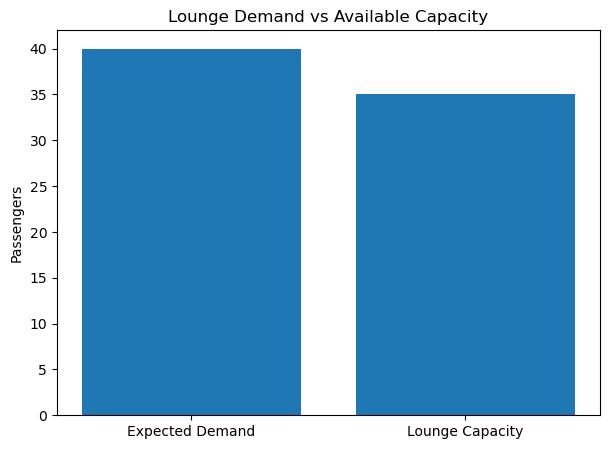

In [84]:
import matplotlib.pyplot as plt

total_demand = 40.0
capacity = 35

plt.figure(figsize=(7, 5))

plt.bar(
    ["Expected Demand", "Lounge Capacity"],
    [total_demand, capacity]
)

plt.ylabel("Passengers")
plt.title("Lounge Demand vs Available Capacity")

plt.show()

## 10. Future Schedule Planning

The framework is applied to an illustrative future schedule to demonstrate schedule-level planning.


In [85]:
def estimate_future_flights(future_flights):
    
    results = []
    
    for _, flight in future_flights.iterrows():
        
        demand = estimate_lounge_demand(
            haul=flight["HAUL"],
            arrival_region=flight["ARRIVAL_REGION"],
            time_of_day=flight["TIME_OF_DAY"],
            total_seats=flight["TOTAL_SEATS"]
        )
        
        if demand is None:
            continue
        
        results.append({
            "FLIGHT_ID": flight["FLIGHT_ID"],
            "HAUL": flight["HAUL"],
            "ARRIVAL_REGION": flight["ARRIVAL_REGION"],
            "TIME_OF_DAY": flight["TIME_OF_DAY"],
            "TOTAL_SEATS": flight["TOTAL_SEATS"],
            "TIER1_DEMAND": float(demand["Tier 1"]),
            "TIER2_DEMAND": float(demand["Tier 2"]),
            "TIER3_DEMAND": float(demand["Tier 3"]),
            "TOTAL_LOUNGE_DEMAND": float(
                demand["Total Lounge Demand"]
            )
        })
    
    return pd.DataFrame(results)

In [86]:
future_flights = pd.DataFrame({
    "FLIGHT_ID": ["BA001", "BA002", "BA003", "BA004"],
    "HAUL": ["SHORT", "LONG", "LONG", "SHORT"],
    "ARRIVAL_REGION": ["Europe", "North America", "Asia", "Europe"],
    "TIME_OF_DAY": ["Lunchtime", "Morning", "Afternoon", "Evening"],
    "TOTAL_SEATS": [180, 235, 235, 180]
})

future_flights

,FLIGHT_ID,HAUL,ARRIVAL_REGION,TIME_OF_DAY,TOTAL_SEATS
0,BA001,SHORT,Europe,Lunchtime,180
1,BA002,LONG,North America,Morning,235
2,BA003,LONG,Asia,Afternoon,235
3,BA004,SHORT,Europe,Evening,180


In [87]:
future_demand = estimate_future_flights(future_flights)

future_demand

,FLIGHT_ID,HAUL,ARRIVAL_REGION,TIME_OF_DAY,TOTAL_SEATS,TIER1_DEMAND,TIER2_DEMAND,TIER3_DEMAND,TOTAL_LOUNGE_DEMAND
0,BA001,SHORT,Europe,Lunchtime,180,0.7,8.2,31.1,40.0
1,BA002,LONG,North America,Morning,235,0.5,6.6,25.3,32.4
2,BA003,LONG,Asia,Afternoon,235,0.4,6.8,25.4,32.6
3,BA004,SHORT,Europe,Evening,180,0.6,8.0,30.6,39.2


In [88]:
def analyze_schedule_capacity(future_demand, lounge_capacity):
    
    result = future_demand.copy()
    
    result["UTILIZATION (%)"] = (
        result["TOTAL_LOUNGE_DEMAND"] / lounge_capacity
    ) * 100
    
    result["SHORTFALL"] = (
        result["TOTAL_LOUNGE_DEMAND"] - lounge_capacity
    ).clip(lower=0)
    
    result["RISK"] = result["UTILIZATION (%)"].apply(
        classify_capacity_risk
    )
    
    result["LOUNGE_CAPACITY"] = lounge_capacity
    
    return result

In [89]:
schedule_analysis = analyze_schedule_capacity(
    future_demand,
    lounge_capacity=35
)

schedule_analysis

,FLIGHT_ID,HAUL,ARRIVAL_REGION,TIME_OF_DAY,TOTAL_SEATS,TIER1_DEMAND,TIER2_DEMAND,TIER3_DEMAND,TOTAL_LOUNGE_DEMAND,UTILIZATION (%),SHORTFALL,RISK,LOUNGE_CAPACITY
0,BA001,SHORT,Europe,Lunchtime,180,0.7,8.2,31.1,40.0,114.285714,5.0,High Risk,35
1,BA002,LONG,North America,Morning,235,0.5,6.6,25.3,32.4,92.571429,0.0,Moderate Risk,35
2,BA003,LONG,Asia,Afternoon,235,0.4,6.8,25.4,32.6,93.142857,0.0,Moderate Risk,35
3,BA004,SHORT,Europe,Evening,180,0.6,8.0,30.6,39.2,112.000000,4.2,High Risk,35


In [90]:
high_risk_flights = schedule_analysis[
    schedule_analysis["RISK"] != "Low Risk"
].sort_values(
    "UTILIZATION (%)",
    ascending=False
)

high_risk_flights

,FLIGHT_ID,HAUL,ARRIVAL_REGION,TIME_OF_DAY,TOTAL_SEATS,TIER1_DEMAND,TIER2_DEMAND,TIER3_DEMAND,TOTAL_LOUNGE_DEMAND,UTILIZATION (%),SHORTFALL,RISK,LOUNGE_CAPACITY
0,BA001,SHORT,Europe,Lunchtime,180,0.7,8.2,31.1,40.0,114.285714,5.0,High Risk,35
3,BA004,SHORT,Europe,Evening,180,0.6,8.0,30.6,39.2,112.000000,4.2,High Risk,35
2,BA003,LONG,Asia,Afternoon,235,0.4,6.8,25.4,32.6,93.142857,0.0,Moderate Risk,35
1,BA002,LONG,North America,Morning,235,0.5,6.6,25.3,32.4,92.571429,0.0,Moderate Risk,35


In [91]:
total_demand = schedule_analysis["TOTAL_LOUNGE_DEMAND"].sum()

total_shortfall = schedule_analysis["SHORTFALL"].sum()

average_utilization = schedule_analysis["UTILIZATION (%)"].mean()

number_over_capacity = (
    schedule_analysis["SHORTFALL"] > 0
).sum()

print("Schedule-Level Lounge Planning Summary")
print("--------------------------------------")
print("Total Expected Demand:", round(total_demand, 1))
print("Average Capacity Utilization:", round(average_utilization, 1), "%")
print("Flights Over Capacity:", number_over_capacity)
print("Total Potential Shortfall:", round(total_shortfall, 1))

Schedule-Level Lounge Planning Summary
--------------------------------------
Total Expected Demand: 144.2
Average Capacity Utilization: 103.0 %
Flights Over Capacity: 2
Total Potential Shortfall: 9.2


In [92]:
lookup_table.columns.tolist()

['HAUL',
 'ARRIVAL_REGION',
 'TIME_OF_DAY',
 'NUMBER_OF_FLIGHTS',
 'TOTAL_SEATS',
 'TIER1_PAX',
 'TIER2_PAX',
 'TIER3_PAX',
 'TIER1_PERCENT',
 'TIER2_PERCENT',
 'TIER3_PERCENT',
 'NO_LOUNGE_PERCENT',
 'TOTAL_PERCENT']

In [93]:
lookup_table["LOUNGE_DEMAND_RATE"] = (
    lookup_table["TIER1_PERCENT"] +
    lookup_table["TIER2_PERCENT"] +
    lookup_table["TIER3_PERCENT"]
)

In [94]:
top_groups = lookup_table.sort_values(
    "LOUNGE_DEMAND_RATE",
    ascending=False
)

top_groups[
    [
        "HAUL",
        "ARRIVAL_REGION",
        "TIME_OF_DAY",
        "TIER1_PERCENT",
        "TIER2_PERCENT",
        "TIER3_PERCENT",
        "LOUNGE_DEMAND_RATE"
    ]
].head(10)

,HAUL,ARRIVAL_REGION,TIME_OF_DAY,TIER1_PERCENT,TIER2_PERCENT,TIER3_PERCENT,LOUNGE_DEMAND_RATE
14,SHORT,Europe,Lunchtime,0.39,4.55,17.28,22.22
13,SHORT,Europe,Evening,0.33,4.45,17.00,21.78
15,SHORT,Europe,Morning,0.34,4.36,16.74,21.44
12,SHORT,Europe,Afternoon,0.34,4.31,16.59,21.24
0,LONG,Asia,Afternoon,0.17,2.88,10.83,13.88
11,LONG,North America,Morning,0.21,2.83,10.76,13.80
7,LONG,Middle East,Morning,0.19,2.79,10.60,13.58
8,LONG,North America,Afternoon,0.20,2.76,10.53,13.49
10,LONG,North America,Lunchtime,0.18,2.76,10.49,13.43
6,LONG,Middle East,Lunchtime,0.19,2.70,10.36,13.25


In [95]:
highest_demand_group = top_groups.iloc[0]

highest_demand_group

HAUL                      SHORT
ARRIVAL_REGION           Europe
TIME_OF_DAY           Lunchtime
NUMBER_OF_FLIGHTS           757
TOTAL_SEATS              136260
TIER1_PAX                   537
TIER2_PAX                  6198
TIER3_PAX                 23539
TIER1_PERCENT              0.39
TIER2_PERCENT              4.55
TIER3_PERCENT             17.28
NO_LOUNGE_PERCENT         77.78
TOTAL_PERCENT             100.0
LOUNGE_DEMAND_RATE        22.22
Name: 14, dtype: object

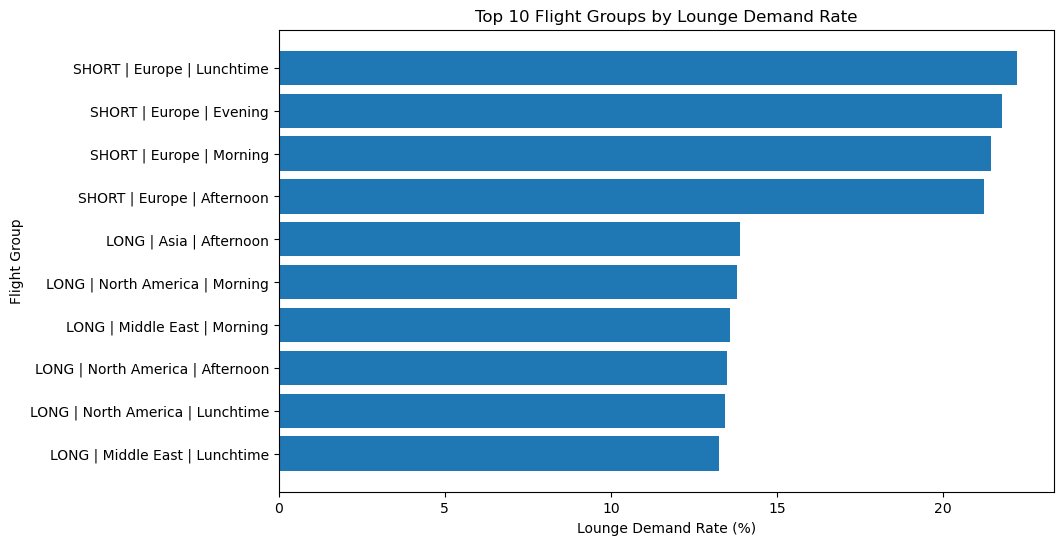

In [96]:
top10 = top_groups.head(10).copy()

top10["GROUP"] = (
    top10["HAUL"] + " | " +
    top10["ARRIVAL_REGION"] + " | " +
    top10["TIME_OF_DAY"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["GROUP"],
    top10["LOUNGE_DEMAND_RATE"]
)

plt.xlabel("Lounge Demand Rate (%)")
plt.ylabel("Flight Group")
plt.title("Top 10 Flight Groups by Lounge Demand Rate")

plt.gca().invert_yaxis()

plt.show()

## 11. Sensitivity Analysis

Aircraft capacity and future demand growth are tested to understand potential capacity pressure.


In [97]:
def seat_sensitivity(
    haul,
    arrival_region,
    time_of_day,
    seat_options
):
    
    matching_group = lookup_table[
        (lookup_table["HAUL"] == haul) &
        (lookup_table["ARRIVAL_REGION"] == arrival_region) &
        (lookup_table["TIME_OF_DAY"] == time_of_day)
    ]
    
    if matching_group.empty:
        print("No matching flight group found.")
        return None
    
    demand_rate = (
        matching_group.iloc[0]["LOUNGE_DEMAND_RATE"] / 100
    )
    
    results = []
    
    for seats in seat_options:
        
        expected_demand = seats * demand_rate
        
        results.append({
            "TOTAL_SEATS": seats,
            "EXPECTED_LOUNGE_DEMAND": round(
                expected_demand, 1
            )
        })
    
    return pd.DataFrame(results)

In [98]:
seat_analysis = seat_sensitivity(
    haul="SHORT",
    arrival_region="Europe",
    time_of_day="Lunchtime",
    seat_options=[150, 180, 200, 235, 300]
)

seat_analysis

,TOTAL_SEATS,EXPECTED_LOUNGE_DEMAND
0,150,33.3
1,180,40.0
2,200,44.4
3,235,52.2
4,300,66.7


In [99]:
def capacity_sensitivity(
    expected_demand,
    capacity_options,
    growth_rates
):
    
    results = []
    
    for growth in growth_rates:
        
        projected_demand = expected_demand * (1 + growth)
        
        for capacity in capacity_options:
            
            utilization = (
                projected_demand / capacity
            ) * 100
            
            shortfall = max(
                projected_demand - capacity,
                0
            )
            
            results.append({
                "DEMAND_GROWTH": f"{int(growth * 100)}%",
                "PROJECTED_DEMAND": round(projected_demand, 1),
                "LOUNGE_CAPACITY": capacity,
                "UTILIZATION (%)": round(utilization, 1),
                "SHORTFALL": round(shortfall, 1)
            })
    
    return pd.DataFrame(results)

In [100]:
capacity_analysis = capacity_sensitivity(
    expected_demand=40,
    capacity_options=[30, 35, 40, 45, 50],
    growth_rates=[0, 0.10, 0.20, 0.30]
)

capacity_analysis

,DEMAND_GROWTH,PROJECTED_DEMAND,LOUNGE_CAPACITY,UTILIZATION (%),SHORTFALL
0,0%,40.0,30,133.3,10.0
1,0%,40.0,35,114.3,5.0
2,0%,40.0,40,100.0,0.0
3,0%,40.0,45,88.9,0.0
4,0%,40.0,50,80.0,0.0
5,10%,44.0,30,146.7,14.0
6,10%,44.0,35,125.7,9.0
7,10%,44.0,40,110.0,4.0
8,10%,44.0,45,97.8,0.0
9,10%,44.0,50,88.0,0.0


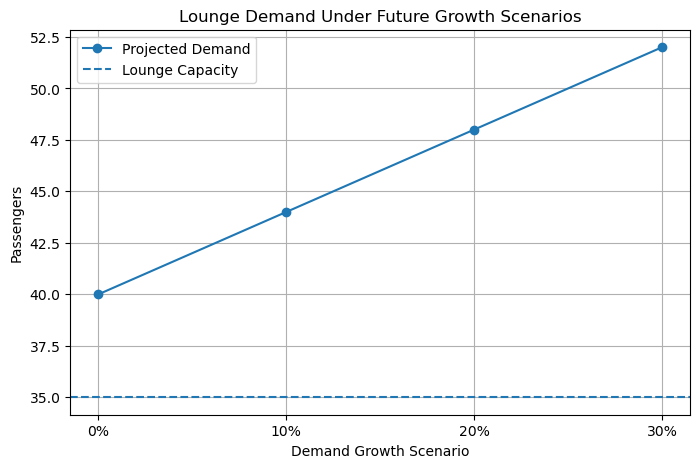

In [101]:
plt.figure(figsize=(8, 5))

plt.plot(
    scenario_df["Demand Growth"],
    scenario_df["Projected Demand"],
    marker="o",
    label="Projected Demand"
)

plt.axhline(
    y=scenario_df["Capacity"].iloc[0],
    linestyle="--",
    label="Lounge Capacity"
)

plt.xlabel("Demand Growth Scenario")
plt.ylabel("Passengers")
plt.title("Lounge Demand Under Future Growth Scenarios")

plt.legend()
plt.grid(True)

plt.show()

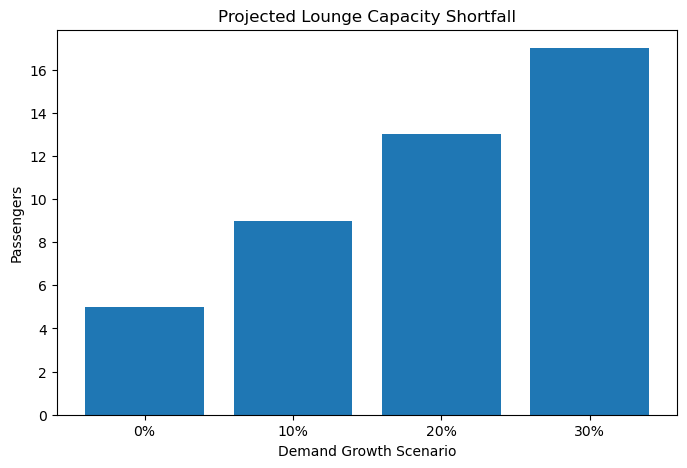

In [102]:
plt.figure(figsize=(8, 5))

plt.bar(
    scenario_df["Demand Growth"],
    scenario_df["Shortfall"]
)

plt.xlabel("Demand Growth Scenario")
plt.ylabel("Passengers")
plt.title("Projected Lounge Capacity Shortfall")

plt.show()

#Model Evaluation and Method Selection
I evaluated whether supervised machine-learning models could reliably predict lounge demand. However, the models did not outperform the baseline, so I selected a transparent lookup-based estimation framework that better aligned with the available data and business requirement."

## 12. Executive Insights


# Executive Insights

### 1. Highest-Demand Flight Profile
The highest lounge-demand rate was observed for SHORT-haul flights to Europe during Lunchtime, with an estimated lounge-demand rate of 22.22%.

### 2. Current Capacity Risk
For the selected SHORT-haul Europe Lunchtime profile with 180 seats, expected lounge demand was approximately 40 passengers against a lounge capacity of 35. This corresponds to 114.3% capacity utilization and a potential shortfall of 5 passengers.

### 3. Future Demand Risk
Under a 30% demand-growth scenario, expected lounge demand increased from 40 to 52 passengers. At a capacity of 35, this resulted in 148.6% utilization and a potential shortfall of 17 passengers.

### 4. Aircraft Capacity Sensitivity
For the highest-demand flight profile, increasing total aircraft capacity from 150 to 300 seats increased estimated lounge demand from approximately 33.3 to 66.7 passengers.

### 5. Schedule-Level Planning
For the illustrative future schedule, total expected lounge demand was 144.2 passengers, with average capacity utilization of 103.0%. Two of the four example flights exceeded the assumed lounge capacity, resulting in a total potential shortfall of 9.2 passengers.

### Overall Insight
The analysis demonstrates that lounge demand can vary substantially depending on flight characteristics and aircraft capacity. A grouping-based lookup approach provides a practical way to estimate demand for future flight schedules and evaluate potential lounge-capacity risks without requiring exact aircraft or passenger-level information.

# Business Recommendations

### 1. Prioritize High-Demand Flight Groups
Airport planning teams should pay particular attention to flight groups with higher estimated lounge-demand rates, especially SHORT-haul European services during peak periods.

### 2. Use Capacity Scenarios for Planning
Lounge capacity decisions should consider not only current demand but also potential demand growth. Scenario analysis can identify capacity shortfalls before they become operational problems.

### 3. Consider Aircraft Changes
Aircraft substitutions that increase passenger capacity can significantly increase expected lounge demand. Capacity planning should therefore account for potential changes in aircraft configuration.

### 4. Use the Lookup Table for Early-Stage Planning
The lookup methodology can provide a rapid demand estimate when detailed passenger-level information is unavailable. This makes it useful for preliminary airport planning and what-if analysis.

### 5. Recalibrate with New Operational Data
As new flight and passenger data becomes available, the grouping and eligibility rates should be recalculated to keep the estimates aligned with changing travel patterns.

# Conclusion

This project developed a data-driven framework for estimating airline lounge demand using historical flight and passenger eligibility patterns.

Rather than relying on exact flight or aircraft information, flights were grouped using operational characteristics such as haul type, arrival region, and time of day. Historical eligibility rates were then converted into a lookup table that can be applied to future flight profiles.

The framework was extended to evaluate lounge capacity utilization, identify potential shortfalls, classify capacity risk, and perform demand-growth and aircraft-capacity sensitivity analysis.

The results demonstrate how historical operational data can be transformed into actionable planning insights for airport infrastructure and lounge-capacity decisions.

The approach is designed as a decision-support framework rather than a real-time prediction system and can be recalibrated as new operational data becomes available.

### Project Positioning

This notebook is a **historical-data decision-support project**, not a real-time production system. Its main contribution is a transparent lookup-based framework that translates historical lounge-eligibility patterns into demand and capacity-planning decisions. The framework can be recalibrated when new operational data becomes available.
